# LSTM Версия

Данные загружены из кэша.
Epoch 1/40 | Train Loss: 0.0086 | Val Loss: 0.0045
Epoch 2/40 | Train Loss: 0.0028 | Val Loss: 0.0049
Epoch 3/40 | Train Loss: 0.0022 | Val Loss: 0.0043
Epoch 4/40 | Train Loss: 0.0022 | Val Loss: 0.0018
Epoch 5/40 | Train Loss: 0.0019 | Val Loss: 0.0014
Epoch 6/40 | Train Loss: 0.0021 | Val Loss: 0.0011
Epoch 7/40 | Train Loss: 0.0017 | Val Loss: 0.0011
Epoch 8/40 | Train Loss: 0.0017 | Val Loss: 0.0009
Epoch 9/40 | Train Loss: 0.0020 | Val Loss: 0.0017
Epoch 10/40 | Train Loss: 0.0016 | Val Loss: 0.0010
Epoch 11/40 | Train Loss: 0.0019 | Val Loss: 0.0044
Epoch 12/40 | Train Loss: 0.0017 | Val Loss: 0.0009
Epoch 13/40 | Train Loss: 0.0019 | Val Loss: 0.0009
Epoch 14/40 | Train Loss: 0.0015 | Val Loss: 0.0009
Epoch 15/40 | Train Loss: 0.0016 | Val Loss: 0.0011
Epoch 16/40 | Train Loss: 0.0017 | Val Loss: 0.0008
Epoch 17/40 | Train Loss: 0.0016 | Val Loss: 0.0021
Epoch 18/40 | Train Loss: 0.0015 | Val Loss: 0.0006
Epoch 19/40 | Train Loss: 0.0016 | Val Loss: 0.

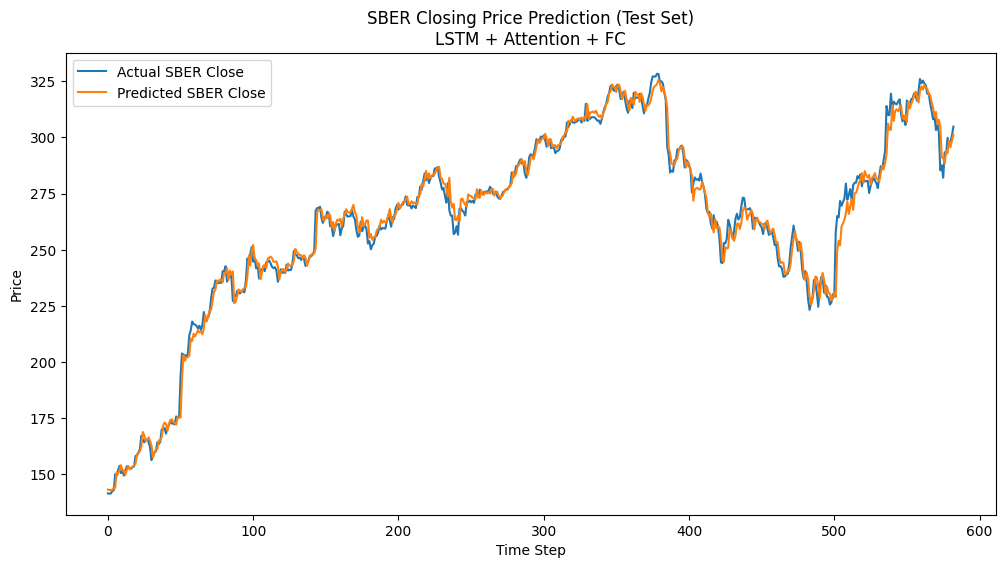


Backtest (комиссии, SL/TP): итоговый баланс = 202845.56, P&L = 102845.56
Hit Rate: 56.36%
Max Drawdown: -8.97%
Sharpe Ratio (annualized): 1.97


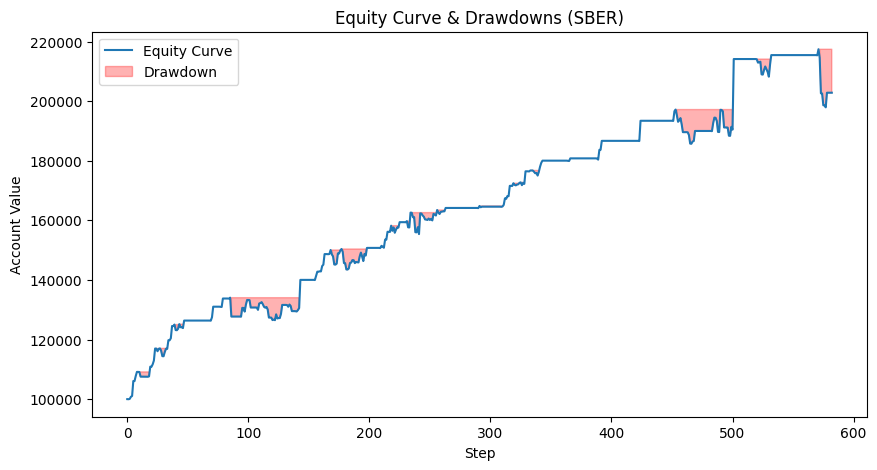

✔ Model state_dict and scalers saved.


In [ ]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ----------------------- Настройки и финансовые константы -----------------------
SEQ_LENGTH = 20
TRAIN_TEST_RATIO = 0.8
RSI_PERIOD = 14
SMA_WINDOW = 14
SEED = 42
TICKER = "SBER"

torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------- 1. Загрузка данных с MOEX -----------------------
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

# ----------------------- 2. Технические индикаторы и финансовые преобразования -----------------------
def compute_rsi(series: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_sma(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    return series.rolling(window=window).mean()

def compute_log_returns(series: pd.Series, window: int = 1) -> pd.Series:
    """Логарифмическая доходность для стабилизации ряда."""
    return np.log(series).diff(window)

def compute_volatility(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    """Волатильность как стандартное отклонение лог-доходностей."""
    returns = compute_log_returns(series)
    return returns.rolling(window=window).std()

def compute_macd(series: pd.Series, fast_period=12, slow_period=26, signal_period=9):
    """MACD: разница между быстрым и медленным EMA, сигнальная линия и гистограмма."""
    ema_fast = series.ewm(span=fast_period, adjust=False).mean()
    ema_slow = series.ewm(span=slow_period, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist

def compute_bollinger_bands(series: pd.Series, window=20, num_std=2):
    """Bollinger Bands: верхняя, нижняя границы и SMA."""
    sma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    return upper_band, lower_band, sma

def compute_atr(df: pd.DataFrame, ticker: str, window: int = 14) -> pd.Series:
    """ATR: средний истинный диапазон для оценки волатильности."""
    high_col = f"HIGH_{ticker}"
    low_col = f"LOW_{ticker}"
    close_col = f"CLOSE_{ticker}"
    high_low = df[high_col] - df[low_col]
    high_prev_close = np.abs(df[high_col] - df[close_col].shift(1))
    low_prev_close = np.abs(df[low_col] - df[close_col].shift(1))
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    return atr

# ----------------------- 3. Загрузка и кэширование данных -----------------------
def load_raw_data(ticker=TICKER, cache_file="raw_moex_data.pkl"):
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print(f"Загружаем данные {ticker} с MOEX...")
    ticker_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if ticker_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [ticker_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    # Переименовываем столбцы для выбранного тикера
    ticker_df.rename(columns={
        "CLOSE": f"CLOSE_{ticker}",
        "OPEN": f"OPEN_{ticker}",
        "HIGH": f"HIGH_{ticker}",
        "LOW": f"LOW_{ticker}",
        "VOLUME": f"VOL_{ticker}"
    }, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    ticker_df = ticker_df[["TRADEDATE", f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = ticker_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                         .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

# ----------------------- 4. Подготовка данных для модели -----------------------
def create_sequences(X, y, seq_length=SEQ_LENGTH):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

def prepare_data(raw_df: pd.DataFrame, ticker=TICKER):
    df = raw_df.copy()
    
    # Исходные финансовые признаки для выбранного тикера
    close_col = f"CLOSE_{ticker}"
    df['LOG_RETURNS'] = compute_log_returns(df[close_col])
    df['RSI'] = compute_rsi(df[close_col])
    df['SMA'] = compute_sma(df[close_col])
    df['VOLATILITY'] = compute_volatility(df[close_col])
    
    # Преобразование SMA в доходность (индикатор тренда)
    df['SMA_RETURNS'] = compute_log_returns(df['SMA'])
    
    # Дополнительные индикаторы:
    macd_line, macd_signal, macd_hist = compute_macd(df[close_col])
    df['MACD_LINE'] = macd_line
    df['MACD_SIGNAL'] = macd_signal
    df['MACD_HIST'] = macd_hist

    bb_upper, bb_lower, bb_middle = compute_bollinger_bands(df[close_col])
    df['BB_UPPER'] = bb_upper
    df['BB_LOWER'] = bb_lower
    df['BB_MIDDLE'] = bb_middle

    df['ATR'] = compute_atr(df, ticker=ticker, window=SMA_WINDOW)
    
    # Удаляем строки с NAN после вычислений
    df = df.dropna().reset_index(drop=True)
    
    # Разбиение на обучающую и тестовую выборки (с сохранением временного порядка)
    split_idx = int(len(df) * TRAIN_TEST_RATIO)
    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()
    
    # Выбор признаков.
    features = [
        f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}",
        "CLOSE_IMOEX", "CLOSE_USD",
        "RSI", "SMA_RETURNS", "VOLATILITY", "LOG_RETURNS",
        "MACD_LINE", "MACD_SIGNAL", "MACD_HIST",
        "BB_UPPER", "BB_LOWER", "BB_MIDDLE",
        "ATR"
    ]
    target = f"CLOSE_{ticker}"  # прогнозируем цену закрытия выбранного тикера
    
    X_train = train_df[features].values.astype(float)
    X_test  = test_df[features].values.astype(float)
    y_train = train_df[[target]].values.astype(float)
    y_test  = test_df[[target]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(X_train)
    scaler_y.fit(y_train)
    
    X_train_scaled = scaler_X.transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)
    
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)
    
    train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                  torch.tensor(y_train_seq, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32),
                                 torch.tensor(y_test_seq, dtype=torch.float32))
    
    # Для наивного прогноза определяем индекс цены закрытия в features
    close_idx = features.index(f"CLOSE_{ticker}")
    
    return train_dataset, test_dataset, scaler_X, scaler_y, close_idx, len(features)

# ----------------------- 5. Определение модели (LSTM + Attention) -----------------------
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = torch.sum(x * alpha, dim=1)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ----------------------- 6. Обучение модели с ранней остановкой -----------------------
def train_final_model(ticker=TICKER):
    # Загрузка и подготовка данных
    raw_df = load_raw_data(ticker=ticker)
    train_dataset, test_dataset, scaler_X, scaler_y, close_idx, num_features = prepare_data(raw_df, ticker=ticker)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Гиперпараметры модели
    lstm_units = 240
    fc_units = 127
    dropout_rate = 0.13351299266216415
    lr = 0.0026886688214184788
    weight_decay = 4.7664426132397547e-05
    
    model = PricePredictionModel(seq_length=SEQ_LENGTH, num_features=num_features, output_dim=1,
                                 lstm_units=lstm_units, fc_units=fc_units, dropout_rate=dropout_rate)
    model.to(device)
    
    # Используем HuberLoss для устойчивости к выбросам
    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            torch.save(model.state_dict(), "best_model.pth")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    model.load_state_dict(best_model_state)
    
    # Оценка модели
    model.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (Huber):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(actuals_inv, preds_inv)
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"\nМетрики для {ticker}:")
    print(f"MSE: {mse_orig:.3f}")
    print(f"RMSE: {rmse_orig:.3f}")
    print(f"MAE: {mae_orig:.3f}")
    print(f"MAPE: {mape_orig:.2f}%")
    
    # Визуализация результатов
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label=f"Actual {ticker} Close")
    plt.plot(preds_inv.flatten(), label=f"Predicted {ticker} Close")
    plt.title(f"{ticker} Closing Price Prediction (Test Set)\nLSTM + Attention + FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    # Сохраняем веса модели
    torch.save(model.state_dict(), 'SBER_model.pth')
    # Сохраняем скейлеры
    pickle.dump(scaler_X, open('SBER_scaler_X.pkl', 'wb'))
    pickle.dump(scaler_y, open('SBER_scaler_y.pkl', 'wb'))
    print("✔ Model state_dict and scalers saved.")


if __name__ == "__main__":
    train_final_model(ticker=TICKER)


# TFE Версия

/Users/nasdorm/.pyenv/versions/3.11.9/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/50 | Train Loss: 0.0163 | Val Loss: 0.0013
Epoch 2/50 | Train Loss: 0.0033 | Val Loss: 0.0014
Epoch 3/50 | Train Loss: 0.0021 | Val Loss: 0.0013
Epoch 4/50 | Train Loss: 0.0021 | Val Loss: 0.0014
Epoch 5/50 | Train Loss: 0.0017 | Val Loss: 0.0006
Epoch 6/50 | Train Loss: 0.0014 | Val Loss: 0.0006
Epoch 7/50 | Train Loss: 0.0015 | Val Loss: 0.0006
Epoch 8/50 | Train Loss: 0.0013 | Val Loss: 0.0019
Epoch 9/50 | Train Loss: 0.0012 | Val Loss: 0.0011
Epoch 10/50 | Train Loss: 0.0012 | Val Loss: 0.0007
Epoch 11/50 | Train Loss: 0.0011 | Val Loss: 0.0008
Epoch 12/50 | Train Loss: 0.0012 | Val Loss: 0.0019
Epoch 13/50 | Train Loss: 0.0010 | Val Loss: 0.0005
Epoch 14/50 | Train Loss: 0.0009 | Val Loss: 0.0014
Epoch 15/50 | Train Loss: 0.0010 | Val Loss: 0.0006
Epoch 16/50 | Train Loss: 0.0009 | Val Loss: 0.0003
Epoch 17/50 | Train Loss: 0.0008 | Val Loss: 0.0007
Epoch 18/50 | Train Loss: 0.0009 | Val Loss: 0.0006
Epoch 19/50 | Train Loss: 0.0010 | Val Loss: 0.0016
Epoch 20/50 | Train L

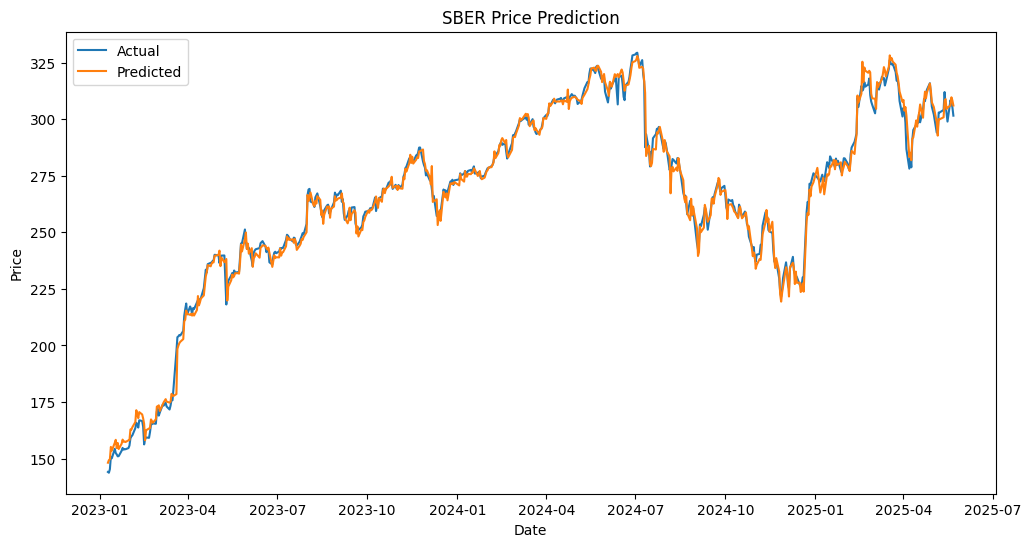

In [1]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ----------------------- Настройки и константы -----------------------
SEQ_LEN = 20
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
D_FF = 256
DROPOUT = 0.1
TICKER = "SBER"
PAGE_LIMIT = 100

# ----------------------- Функция для загрузки данных -----------------------
def fetch_moex_data(security, engine, market, board, start, end):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_rows = []
    offset = 0
    while True:
        params = {"from": start, "till": end, "start": offset, "limit": PAGE_LIMIT}
        resp = requests.get(base_url, params=params)
        if resp.status_code != 200:
            raise RuntimeError(f"MOEX HTTP {resp.status_code}")
        data = resp.json().get("history", {})
        cols = data.get("columns", [])
        rows = data.get("data", [])
        if not rows:
            break
        all_rows.extend(rows)
        if len(rows) < PAGE_LIMIT:
            break
        offset += PAGE_LIMIT
    df = pd.DataFrame(all_rows, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.sort_values('TRADEDATE').reset_index(drop=True)

# ----------------------- Вычисление индикаторов -----------------------
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_sma(series, window=14): return series.rolling(window).mean()

def compute_log_returns(series, window=1): return np.log(series).diff(window)

def compute_volatility(series, window=14): return compute_log_returns(series).rolling(window).std()

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    sig_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, sig_line, macd_line - sig_line

def compute_bollinger_bands(series, window=20, num_std=2):
    sma = series.rolling(window).mean()
    std = series.rolling(window).std()
    return sma + std*num_std, sma - std*num_std

def compute_atr(df, high_col, low_col, close_col, window=14):
    hi, lo, cl = df[high_col], df[low_col], df[close_col]
    tr = pd.concat([hi-lo, (hi-cl.shift()).abs(), (lo-cl.shift()).abs()], axis=1).max(axis=1)
    return tr.rolling(window).mean()

# ----------------------- Подготовка данных для обучения -----------------------
def prepare_df(ticker):
    start, end = "2010-01-01", datetime.today().strftime("%Y-%m-%d")
    df = fetch_moex_data(ticker, 'stock','shares','TQBR', start, end)
    df = df.rename(columns={'OPEN':'OPEN','HIGH':'HIGH','LOW':'LOW','CLOSE':'CLOSE','VOLUME':'VOLUME'})
    df = df[['TRADEDATE','OPEN','HIGH','LOW','CLOSE','VOLUME']].dropna().reset_index(drop=True)
    close = df['CLOSE']
    df['log_ret'] = compute_log_returns(close)
    df['rsi_14'] = compute_rsi(close)
    df['sma_14'] = compute_sma(close)
    df['vol_14'] = compute_volatility(close)
    macd, sig, hist = compute_macd(close)
    df['macd'], df['macd_sig'], df['macd_hist'] = macd, sig, hist
    bb_up, bb_low = compute_bollinger_bands(close)
    df['bb_up'], df['bb_low'] = bb_up, bb_low
    df['atr_14'] = compute_atr(df, 'HIGH','LOW','CLOSE')
    df.dropna(inplace=True)
    return df

def create_sequences(values, seq_len):
    X,y = [],[]
    for i in range(len(values)-seq_len):
        X.append(values[i:i+seq_len]); y.append(values[i+seq_len,2])
    return np.asarray(X), np.asarray(y)

def get_datasets(df):
    feats = [c for c in df.columns if c!='TRADEDATE']
    data = df[feats].values
    scaler = RobustScaler().fit(data)
    data_s = scaler.transform(data)
    X, y = create_sequences(data_s, SEQ_LEN)
    split = int(len(X)*TRAIN_RATIO)
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]
    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
    test_ds  = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.float32))
    test_dates = df['TRADEDATE'].values[SEQ_LEN+split:]
    return train_ds, test_ds, scaler, test_dates

# ----------------------- Transformer модель -----------------------
class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.input_proj = nn.Linear(num_features, D_MODEL)
        self.pos_emb = nn.Parameter(torch.randn(SEQ_LEN, D_MODEL))
        layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=N_HEADS, dim_feedforward=D_FF, dropout=DROPOUT)
        self.transformer = nn.TransformerEncoder(layer, num_layers=N_LAYERS)
        self.decoder = nn.Sequential(nn.Linear(D_MODEL,D_FF), nn.ReLU(), nn.Dropout(DROPOUT), nn.Linear(D_FF,1))
    def forward(self, x):
        x = self.input_proj(x) + self.pos_emb.unsqueeze(0)
        x = x.permute(1,0,2)
        x = self.transformer(x)
        return self.decoder(x[-1]).squeeze()

# ----------------------- Обучение и Валидация -----------------------
def train_and_eval():
    df = prepare_df(TICKER)
    train_ds, test_ds, scaler, test_dates = get_datasets(df)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)
    model = TimeSeriesTransformer(train_ds.tensors[0].shape[-1])
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); model.to(device)
    opt = optim.AdamW(model.parameters(), lr=LR); crit = nn.HuberLoss()
    best_val = float('inf')
    for epoch in range(1,EPOCHS+1):
        model.train(); tl=[]
        for Xb,yb in train_loader:
            Xb,yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); loss=crit(model(Xb), yb); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1); opt.step(); tl.append(loss.item())
        model.eval(); vl=[]
        with torch.no_grad():
            for Xv,yv in test_loader:
                Xv,yv = Xv.to(device), yv.to(device); vl.append(crit(model(Xv), yv).item())
        tr, vr = np.mean(tl), np.mean(vl)
        print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr:.4f} | Val Loss: {vr:.4f}")
        if vr<best_val: best_val=vr; torch.save(model.state_dict(),f"{TICKER}_best.pth")
    print("Training complete. Best Val Loss:", best_val)
    # Прогноз
    model.load_state_dict(torch.load(f"{TICKER}_best.pth")); model.eval()
    preds, acts = [],[]
    with torch.no_grad():
        for Xb,yb in test_loader:
            preds.extend(model(Xb.to(device)).cpu().numpy()); acts.extend(yb.numpy())
    preds, acts = np.array(preds), np.array(acts)
    # Обратное маштабирование
    dummy = np.zeros((len(preds), scaler.scale_.shape[0]))
    close_idx = df.columns.get_loc('CLOSE')-1
    dummy[:,close_idx]=preds; inv_p = scaler.inverse_transform(dummy)[:,close_idx]
    dummy[:,close_idx]=acts; inv_a = scaler.inverse_transform(dummy)[:,close_idx]
    # Метрики
    mse=mean_squared_error(inv_a,inv_p); rmse=np.sqrt(mse)
    mae=mean_absolute_error(inv_a,inv_p); max_err=np.max(np.abs(inv_a-inv_p))
    mape=np.mean(np.abs((inv_a-inv_p)/inv_a))*100
    print(f"Metrics for {TICKER}: MSE:{mse:.3f}, RMSE:{rmse:.3f}, MAE:{mae:.3f}, MAPE:{mape:.2f}%, MaxErr:{max_err:.3f}")
    # График
    plt.figure(figsize=(12,6)); plt.plot(test_dates, inv_a, label='Actual'); plt.plot(test_dates, inv_p, label='Predicted')
    plt.title(f"{TICKER} Price Prediction"); plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.show()

if __name__=='__main__':
    train_and_eval()